# 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset

In [3]:
df = pd.read_csv("/content/ganga_water_quality_clean.csv")
df.head()

,location,year,do,bod,fecal_coliform
0,GANGA AT HARIDWAR D/S,2011,6.7,5.6,1150.0
1,GANGA AT GARHMUKTESHWAR,2011,8.2,3.4,1162.0
2,GANGA AT KANNAUJ U/S (RAJGHAT),2011,7.9,4.5,3042.0
3,"GANGA AT KANNAUJ D/S, U.P",2011,7.8,5.5,3508.0
4,GANGA AT KANPUR U/S (RANIGHAT),2011,8.6,4.3,6667.0


# 3. Dataset Overview

In [4]:
df.shape

(50, 5)

In [5]:
df.columns

Index(['location', 'year', 'do', 'bod', 'fecal_coliform'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        50 non-null     object 
 1   year            50 non-null     int64  
 2   do              50 non-null     float64
 3   bod             50 non-null     float64
 4   fecal_coliform  47 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 2.1+ KB


# 4. Statistical Summary

In [7]:
df.describe()

,year,do,bod,fecal_coliform
count,50.000000,50.000000,50.000000,47.000000
mean,2013.000000,7.578000,4.470000,53017.957447
std,1.428571,0.896317,1.373399,130108.444398
min,2011.000000,5.000000,2.800000,580.000000
25%,2012.000000,7.100000,3.625000,2986.000000
50%,2013.000000,7.750000,4.150000,6475.000000
75%,2014.000000,8.200000,4.975000,28833.500000
max,2015.000000,9.200000,8.400000,592500.000000


# 5. Missing Values Analysis

In [8]:
df.isnull().sum()

,0
location,0
year,0
do,0
bod,0
fecal_coliform,3


# 6. Duplicate Records Check

In [9]:
df.duplicated().sum()

np.int64(0)

# 7. Year Analysis

In [10]:
df["year"].unique()

array([2011, 2012, 2013, 2014, 2015])

# 8. Monitoring Station Analysis

In [11]:
df["location"].nunique()

10

In [12]:
df["location"].value_counts()

,count
location,
GANGA AT HARIDWAR D/S,5
GANGA AT GARHMUKTESHWAR,5
GANGA AT KANNAUJ U/S (RAJGHAT),5
"GANGA AT KANNAUJ D/S, U.P",5
GANGA AT KANPUR U/S (RANIGHAT),5
GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),5
"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",5
"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",5
GANGA AT TRIGHAT (GHAZIPUR),5


# **Year-wise Analysis**

# 9. Average Dissolved Oxygen (DO) by Year

In [13]:
yearly_do = df.groupby("year")["do"].mean()

print(yearly_do)

year
2011    7.55
2012    7.62
2013    7.65
2014    7.35
2015    7.72
Name: do, dtype: float64


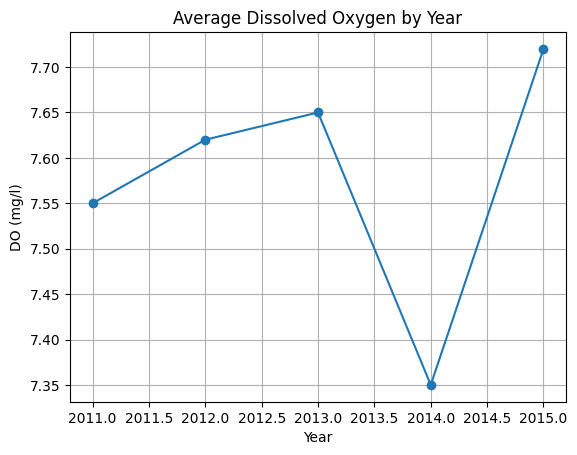

In [14]:
yearly_do.plot(marker="o")

plt.title("Average Dissolved Oxygen by Year")
plt.xlabel("Year")
plt.ylabel("DO (mg/l)")
plt.grid()
plt.show()

# 10. Average Biochemical Oxygen Demand (BOD) by Year

In [15]:
yearly_bod = df.groupby("year")["bod"].mean()

print(yearly_bod)

year
2011    5.20
2012    4.80
2013    4.26
2014    4.15
2015    3.94
Name: bod, dtype: float64


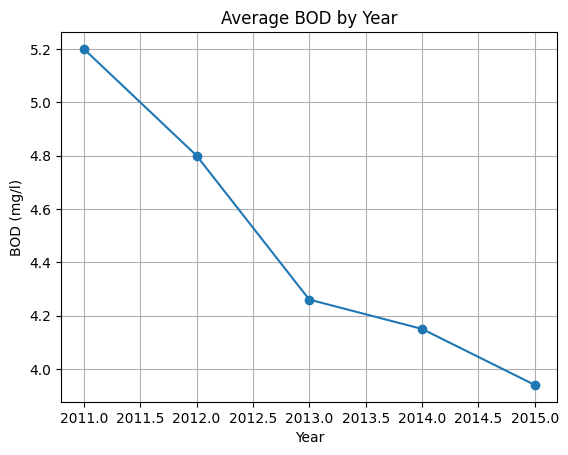

In [16]:
yearly_bod.plot(marker="o")

plt.title("Average BOD by Year")
plt.xlabel("Year")
plt.ylabel("BOD (mg/l)")
plt.grid()
plt.show()

# 11. Average Fecal Coliform by Year

In [17]:
yearly_fecal = df.groupby("year")["fecal_coliform"].mean()

print(yearly_fecal)

year
2011    38121.200000
2012    64982.666667
2013    57543.777778
2014    79880.555556
2015    28896.900000
Name: fecal_coliform, dtype: float64


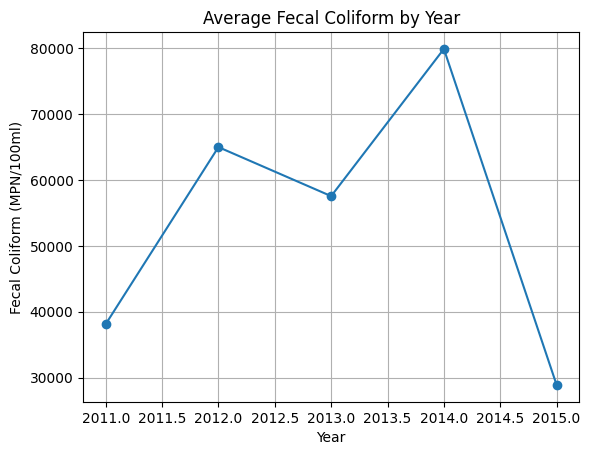

In [18]:
yearly_fecal.plot(marker="o")

plt.title("Average Fecal Coliform by Year")
plt.xlabel("Year")
plt.ylabel("Fecal Coliform (MPN/100ml)")
plt.grid()
plt.show()

# **Station-wise analysis**

# 12. Average Dissolved Oxygen (DO) by Station

In [19]:
station_do = df.groupby("location")["do"].mean().sort_values()

print(station_do)

location
GANGA AT DAKSHINESHWAR                          6.62
GANGA AT KANPUR D/S (JAJMAU PUMPING STATION)    6.80
GANGA AT HARIDWAR D/S                           6.92
GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P     7.48
GANGA AT KANNAUJ D/S, U.P                       7.54
GANGA AT TRIGHAT (GHAZIPUR)                     7.60
GANGA AT ALLAHABAD D/S (SANGAM), U.P.           7.80
GANGA AT KANNAUJ U/S (RAJGHAT)                  8.18
GANGA AT KANPUR U/S (RANIGHAT)                  8.32
GANGA AT GARHMUKTESHWAR                         8.52
Name: do, dtype: float64


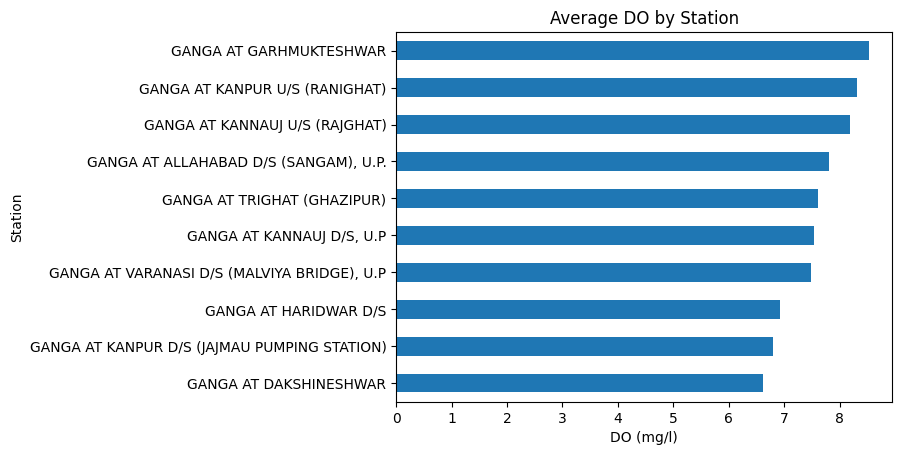

In [20]:
station_do.plot(kind="barh")

plt.title("Average DO by Station")
plt.xlabel("DO (mg/l)")
plt.ylabel("Station")
plt.show()

# 13. Average Biochemical Oxygen Demand (BOD) by Station

In [21]:
station_bod = df.groupby("location")["bod"].mean().sort_values()

print(station_bod)

location
GANGA AT GARHMUKTESHWAR                         3.10
GANGA AT KANPUR U/S (RANIGHAT)                  3.68
GANGA AT KANNAUJ U/S (RAJGHAT)                  3.76
GANGA AT TRIGHAT (GHAZIPUR)                     3.96
GANGA AT ALLAHABAD D/S (SANGAM), U.P.           4.12
GANGA AT KANNAUJ D/S, U.P                       4.26
GANGA AT DAKSHINESHWAR                          4.28
GANGA AT HARIDWAR D/S                           4.82
GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P     5.38
GANGA AT KANPUR D/S (JAJMAU PUMPING STATION)    7.34
Name: bod, dtype: float64


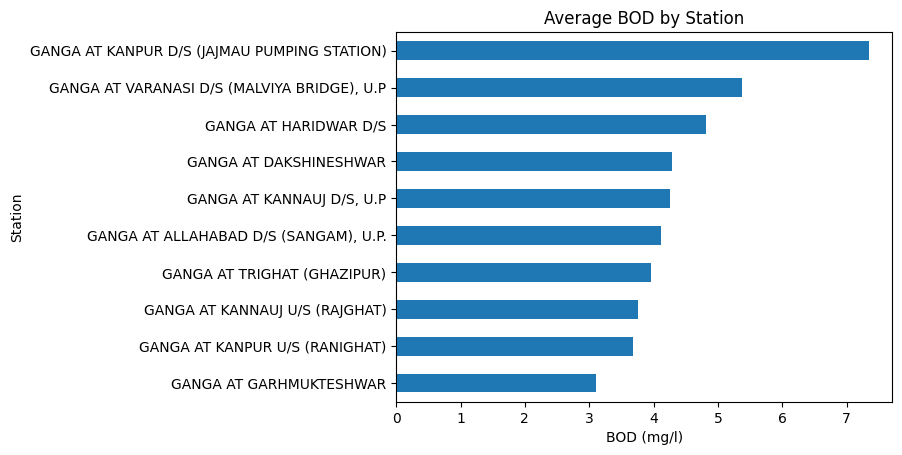

In [22]:
station_bod.plot(kind="barh")

plt.title("Average BOD by Station")
plt.xlabel("BOD (mg/l)")
plt.ylabel("Station")
plt.show()

# 14. Average Fecal Coliform by Station

In [23]:
station_fecal = df.groupby("location")["fecal_coliform"].mean().sort_values()

print(station_fecal)

location
GANGA AT GARHMUKTESHWAR                            861.4
GANGA AT HARIDWAR D/S                              865.0
GANGA AT KANNAUJ U/S (RAJGHAT)                    2939.0
GANGA AT KANNAUJ D/S, U.P                         3600.0
GANGA AT KANPUR U/S (RANIGHAT)                    4347.4
GANGA AT ALLAHABAD D/S (SANGAM), U.P.            12126.6
GANGA AT TRIGHAT (GHAZIPUR)                      15666.8
GANGA AT KANPUR D/S (JAJMAU PUMPING STATION)     27465.0
GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P      34533.4
GANGA AT DAKSHINESHWAR                          396483.2
Name: fecal_coliform, dtype: float64


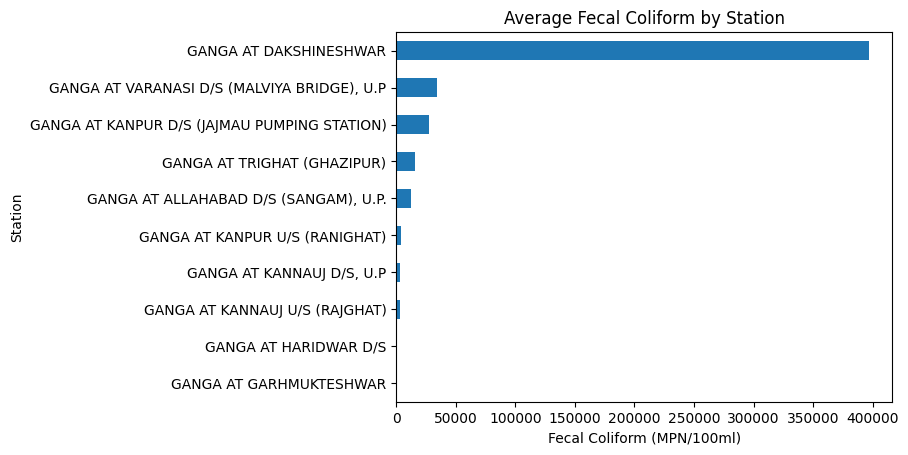

In [24]:
station_fecal.plot(kind="barh")

plt.title("Average Fecal Coliform by Station")
plt.xlabel("Fecal Coliform (MPN/100ml)")
plt.ylabel("Station")
plt.show()

# **Criteria check**

# 15. Water Quality Criteria

In [25]:
df["do_status"] = df["do"] > 5
df["bod_status"] = df["bod"] < 3
df["fecal_status"] = df["fecal_coliform"] < 2500

df.head()

,location,year,do,bod,fecal_coliform,do_status,bod_status,fecal_status
0,GANGA AT HARIDWAR D/S,2011,6.7,5.6,1150.0,True,False,True
1,GANGA AT GARHMUKTESHWAR,2011,8.2,3.4,1162.0,True,False,True
2,GANGA AT KANNAUJ U/S (RAJGHAT),2011,7.9,4.5,3042.0,True,False,False
3,"GANGA AT KANNAUJ D/S, U.P",2011,7.8,5.5,3508.0,True,False,False
4,GANGA AT KANPUR U/S (RANIGHAT),2011,8.6,4.3,6667.0,True,False,False


# 16. Overall criteria result

In [26]:
print("DO passing:", df["do_status"].sum())
print("BOD passing:", df["bod_status"].sum())
print("Fecal Coliform passing:", df["fecal_status"].sum())

DO passing: 49
BOD passing: 5
Fecal Coliform passing: 11


# 17. Station-wise criteria

In [27]:
criteria_by_station = df.groupby("location")[[
    "do_status",
    "bod_status",
    "fecal_status"
]].mean() * 100

criteria_by_station

,do_status,bod_status,fecal_status
location,,,
"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",100.0,0.0,0.0
GANGA AT DAKSHINESHWAR,100.0,0.0,0.0
GANGA AT GARHMUKTESHWAR,100.0,40.0,100.0
GANGA AT HARIDWAR D/S,80.0,20.0,40.0
"GANGA AT KANNAUJ D/S, U.P",100.0,0.0,20.0
GANGA AT KANNAUJ U/S (RAJGHAT),100.0,20.0,40.0
GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),100.0,0.0,0.0
GANGA AT KANPUR U/S (RANIGHAT),100.0,20.0,20.0
GANGA AT TRIGHAT (GHAZIPUR),100.0,0.0,0.0


# 18. Overall water quality status

In [28]:
df["water_quality_status"] = (
    df["do_status"] &
    df["bod_status"] &
    df["fecal_status"]
)

df["water_quality_status"].value_counts()

,count
water_quality_status,
False,47
True,3


**Status Percentage**

In [29]:
df["water_quality_status"].value_counts(normalize=True) * 100

,proportion
water_quality_status,
False,94.0
True,6.0


# **Correlation Analysis**

# 19. Correlation Analysis

In [30]:
correlation = df[["do", "bod", "fecal_coliform"]].corr()

correlation

,do,bod,fecal_coliform
do,1.000000,-0.466569,-0.482608
bod,-0.466569,1.000000,0.019843
fecal_coliform,-0.482608,0.019843,1.000000


# 20. Correlation visualization

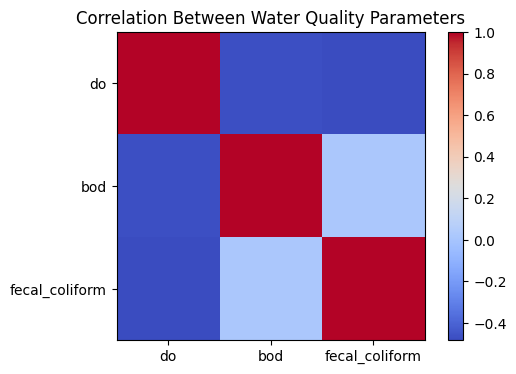

In [31]:
plt.figure(figsize=(6, 4))

plt.imshow(correlation, cmap="coolwarm")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()
plt.title("Correlation Between Water Quality Parameters")

plt.show()

# 21. DO vs BOD

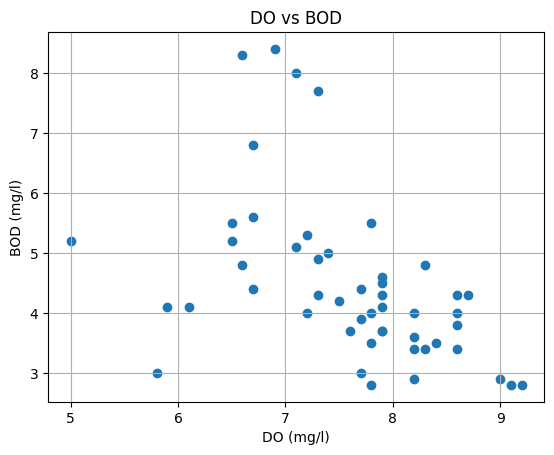

In [32]:
plt.scatter(df["do"], df["bod"])

plt.title("DO vs BOD")
plt.xlabel("DO (mg/l)")
plt.ylabel("BOD (mg/l)")
plt.grid()
plt.show()

# 22. DO vs Fecal_Coliform

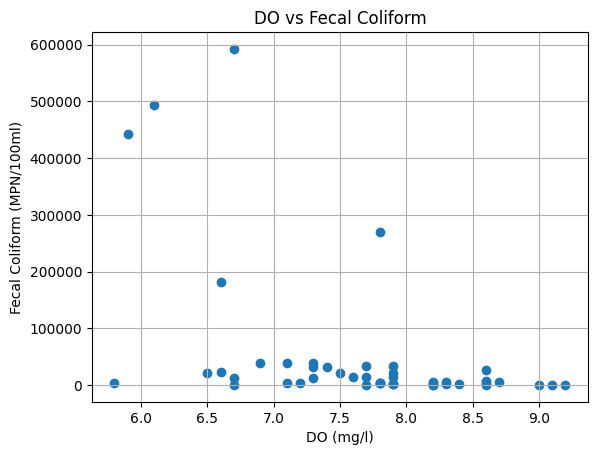

In [33]:
plt.scatter(df["do"], df["fecal_coliform"])

plt.title("DO vs Fecal Coliform")
plt.xlabel("DO (mg/l)")
plt.ylabel("Fecal Coliform (MPN/100ml)")
plt.grid()
plt.show()

# 23. BOD vs Fecal_Coliform

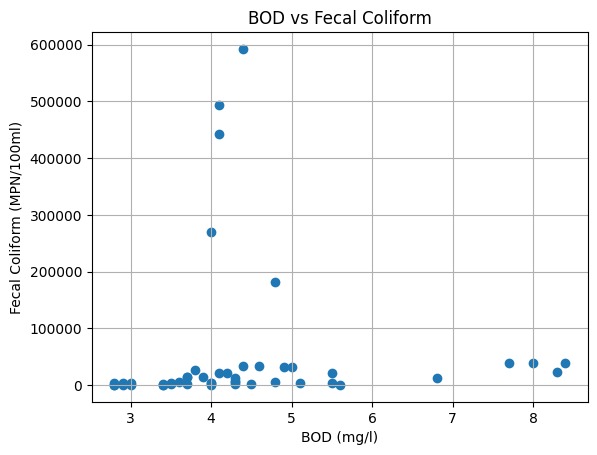

In [34]:
plt.scatter(df["bod"], df["fecal_coliform"])

plt.title("BOD vs Fecal Coliform")
plt.xlabel("BOD (mg/l)")
plt.ylabel("Fecal Coliform (MPN/100ml)")
plt.grid()
plt.show()

# **Outlier Analysis**

# 24. DO and BOD boxplot

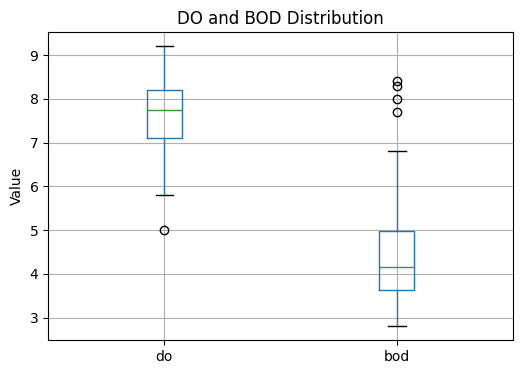

In [35]:
plt.figure(figsize=(6, 4))

df[["do", "bod"]].boxplot()

plt.title("DO and BOD Distribution")
plt.ylabel("Value")

plt.show()

# 25. Fecal_Coliform

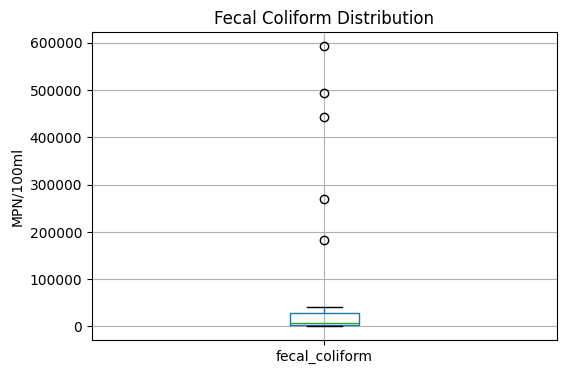

In [36]:
plt.figure(figsize=(6, 4))

df[["fecal_coliform"]].boxplot()

plt.title("Fecal Coliform Distribution")
plt.ylabel("MPN/100ml")

plt.show()

# **Final Findings**

# EDA Findings

- The dataset contains 50 observations from 10 Ganga River monitoring stations for the years 2011 to 2015.

- Dissolved Oxygen (DO), Biochemical Oxygen Demand (BOD), and Fecal Coliform show variations across different years and monitoring stations.

- DO values vary across stations and years, indicating changes in water conditions over time.

- BOD values also vary across locations. Higher BOD values indicate higher organic pollution.

- Fecal Coliform shows a large variation between different monitoring stations.

- The year-wise analysis shows that water-quality parameters change over time.

- The station-wise analysis shows that water quality is not uniform across the Ganga River.

- Based on the selected criteria, DO should be greater than 5 mg/L, BOD should be less than 3 mg/L, and Fecal Coliform should be less than 2500 MPN/100ml.

- Several observations do not satisfy one or more of these water-quality criteria.

- Correlation analysis was performed to understand the relationships between DO, BOD, and Fecal Coliform.

- The Fecal Coliform boxplot shows a highly spread distribution with some potential outliers.

- Missing values were observed in the Fecal Coliform column and will need to be handled before predictive modeling.

## Overall Finding

The EDA shows that Ganga River water quality varies across different monitoring stations and years. The significant variation in DO, BOD, and Fecal Coliform indicates that the dataset can be used for further feature engineering and water-quality prediction.